# 🎵 Music Recommendation System — Exploratory Data Analysis

This notebook performs an end-to-end exploratory data analysis on the Spotify music dataset.
We load four datasets, inspect their structure, engineer features, visualize key patterns, and apply clustering.

## 📦 Imports

In [22]:
import sys
!{sys.executable} -m pip install wordcloud seaborn plotly scikit-learn -q

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style='darkgrid')
%matplotlib inline

---
## 1️⃣ Load Datasets

In [24]:
# Step 1: Read the main dataset
data = pd.read_csv('../data/data.csv')

# Step 2: Read the genre dataset
genre_data = pd.read_csv('../data/data_by_genres.csv')

# Step 3: Read the year dataset
year_data = pd.read_csv('../data/data_by_year.csv')

# Step 4: Read the artist dataset
artist_data = pd.read_csv('../data/data_by_artist.csv')

---
## 2️⃣ Preview Data — First 2 Rows

In [25]:
print("── data ──")
data.head(2)

── data ──


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936


In [26]:
print("── genre_data ──")
genre_data.head(2)

── genre_data ──


,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.3616,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.1310,-16.854000,0.076817,120.285667,0.221750,52.500000,5


In [27]:
print("── year_data ──")
year_data.head(2)

── year_data ──


,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.20571,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.24072,-19.275282,0.116655,100.884521,0.535549,0.140845,10


In [28]:
print("── artist_data ──")
artist_data.head(2)

── year_data ──


,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.20571,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.24072,-19.275282,0.116655,100.884521,0.535549,0.140845,10


---
## 3️⃣ Dataset Info

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [30]:
genre_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2973 entries, 0 to 2972
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mode              2973 non-null   int64  
 1   genres            2973 non-null   object 
 2   acousticness      2973 non-null   float64
 3   danceability      2973 non-null   float64
 4   duration_ms       2973 non-null   float64
 5   energy            2973 non-null   float64
 6   instrumentalness  2973 non-null   float64
 7   liveness          2973 non-null   float64
 8   loudness          2973 non-null   float64
 9   speechiness       2973 non-null   float64
 10  tempo             2973 non-null   float64
 11  valence           2973 non-null   float64
 12  popularity        2973 non-null   float64
 13  key               2973 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 325.3+ KB


---
## 4️⃣ Feature Engineering — `decade` Column

In [31]:
# Create a decade column using apply() and a lambda function
# e.g., year 1984 → 1980, year 2003 → 2000
data['decade'] = data['year'].apply(lambda year: (year // 10) * 10)

print("Sample — year vs decade:")
data[['year', 'decade']].head()

Sample — year vs decade:


,year,decade
0,1921,1920
1,1921,1920
2,1921,1920
3,1921,1920
4,1921,1920


---
## 5️⃣ Distribution of Tracks Across Decades

C:\Users\HP\AppData\Local\Temp\ipykernel_22032\1347028717.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




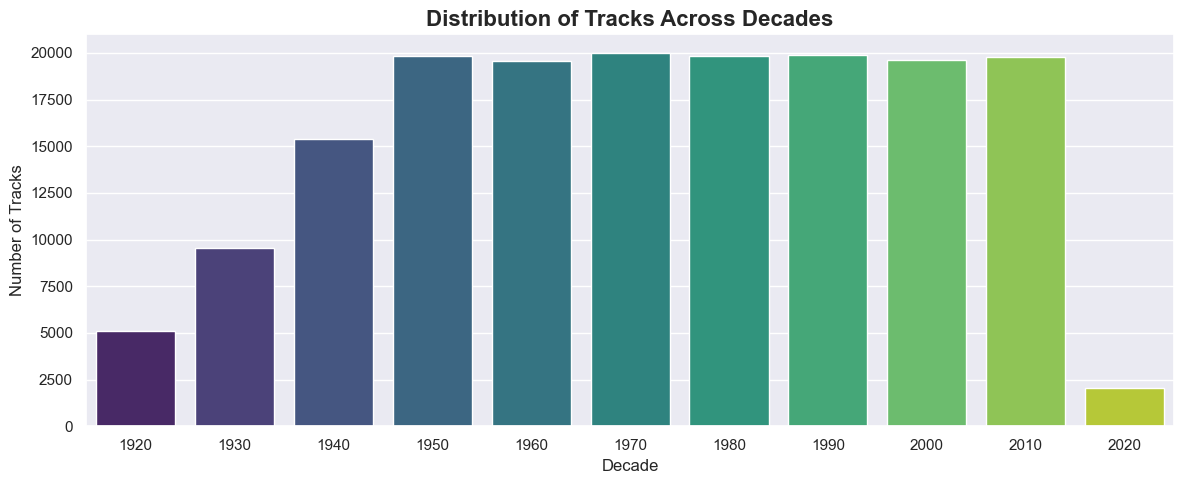

In [32]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=data,
    x='decade',
    palette='viridis',
    order=sorted(data['decade'].unique())
)
plt.title('Distribution of Tracks Across Decades', fontsize=16, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

---
## 6️⃣ Trend of Various Sound Features Over Decades

In [33]:
sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']

fig = px.line(
    year_data,
    x='year',
    y=sound_features,
    title='Trend of various sound features over decades'
)
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Feature Value',
    legend_title='Sound Feature'
)
fig.show()

---
## 7️⃣ Trend of Loudness Over Decades

In [34]:
fig = px.line(
    year_data,
    x='year',
    y='loudness',
    title='Trend of loudness over decades'
)
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Loudness (dB)'
)
fig.show()

---
## 8️⃣ Sound Features for Top 10 Genres by Popularity

In [35]:
# Identify the top 10 genres based on popularity
top10_genres = genre_data.nlargest(10, 'popularity')

fig = px.bar(
    top10_genres,
    x='genres',
    y=['valence', 'energy', 'danceability', 'acousticness'],
    barmode='group',
    title='Trend of various sound features over top 10 genres'
)
fig.update_layout(
    xaxis_title='Genre',
    yaxis_title='Feature Value',
    legend_title='Sound Feature',
    xaxis_tickangle=-30
)
fig.show()

---
## 9️⃣ Word Cloud — Genres

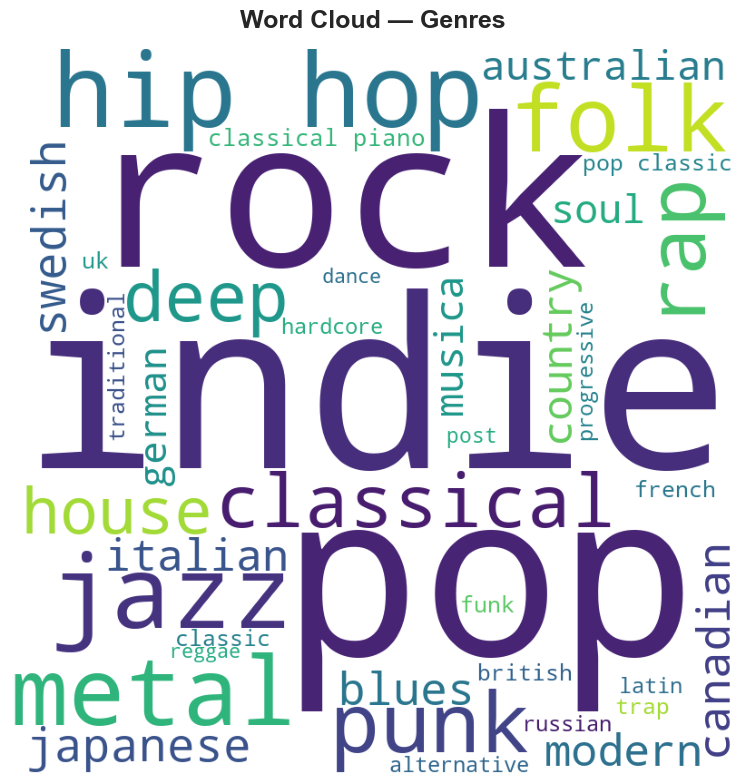

In [36]:
# Build a single string of all genre names
comment_words = ' '.join(genre_data['genres'].dropna().astype(str).values)
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud — Genres', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 🔟 Word Cloud — Artists

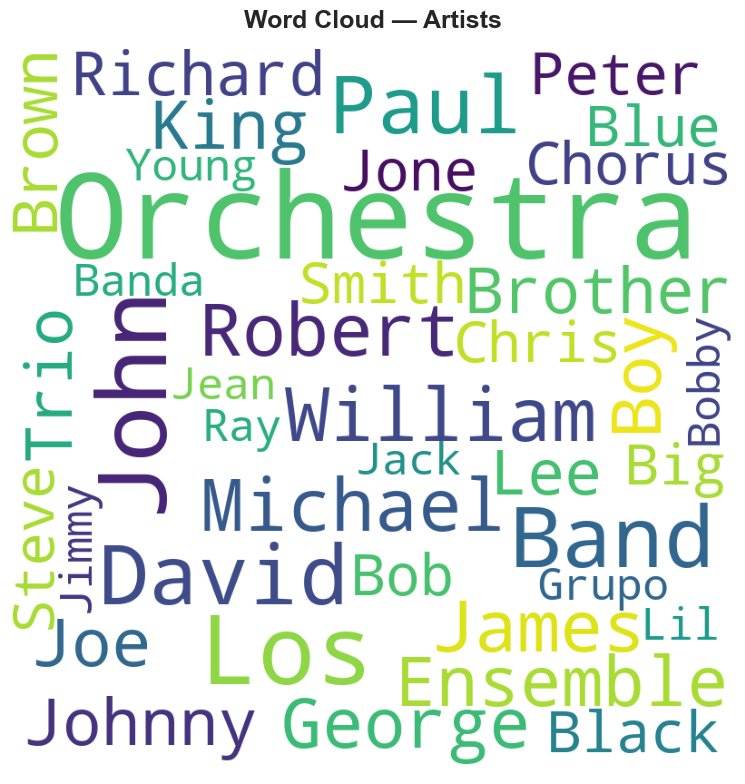

In [37]:
# Build a single string of all artist names
comment_words = ' '.join(artist_data['artists'].dropna().astype(str).values)
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    min_word_length=3,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud — Artists', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Top 10 Artists — Most Songs Produced

In [38]:
# Top 10 artists by number of songs produced
top10_most_song_produced_artists = artist_data.nlargest(10, 'count')

top10_most_song_produced_artists[['count', 'artists']].sort_values('count', ascending=False)

,count,artists
8367,3169,Francisco Canaro
28561,2422,Эрнест Хемингуэй
28560,2136,Эрих Мария Ремарк
8434,1459,Frank Sinatra
10714,1256,Ignacio Corsini
27109,1200,Vladimir Horowitz
1682,1146,Arturo Toscanini
2707,1103,Billie Holiday
12378,1061,Johnny Cash
7426,1023,Elvis Presley


---
## 1️⃣2️⃣ Top 10 Artists — Highest Popularity Score

In [39]:
# Top 10 artists by popularity score
top10_popular_artists = artist_data.nlargest(10, 'popularity')

top10_popular_artists[['popularity', 'artists']].sort_values('popularity', ascending=False)

,popularity,artists
20966,93.0,Ritt Momney
14354,92.0,Lele Pons
15070,90.0,Los Legendarios
11764,89.0,Jerry Di
7463,88.0,Emilee
23687,88.0,Surf Mesa
28263,88.0,salem ilese
213,87.0,A7S
2343,86.0,Beltito
14378,86.0,Lenny Santos


---
## ✅ Conclusion

This exploratory analysis of the Spotify dataset has revealed several key insights about music trends over the decades:

### 📊 Track Distribution
- The dataset is heavily skewed toward **modern music (2000s–2020s)**, with an exponential increase in the number of tracks per decade — reflecting both the digitization of music and the explosive growth of streaming platforms.

### 🎵 Sound Feature Trends
- **Acousticness** has declined sharply over time, driven by the rise of electric and electronic music production.
- **Energy** and **danceability** have steadily increased, reflecting the dominance of up-tempo genres like pop, hip-hop, and EDM in recent decades.
- **Instrumentalness** has dropped significantly since the 1960s, as vocal-driven tracks became the industry standard.
- **Valence** (musical positivity) has shown a slight downward trend in recent years, suggesting that modern music trends toward more emotionally complex or darker tones.

### 🔊 Loudness
- Loudness has increased dramatically from the 1920s to the 2000s — a well-documented phenomenon known as the **"Loudness War"**, where mastering engineers increasingly maximized volume to stand out on radio and streaming platforms.

### 🎸 Genre Insights
- The top 10 genres by popularity are dominated by **mainstream pop and hip-hop adjacent genres**, which score high on energy and danceability but lower on acousticness.
- The genre word cloud highlights a rich diversity in musical styles, ranging from classical and jazz to electronic subgenres.

### 🎤 Artist Insights
- The most **prolific artists** (by song count) are not always the most **popular**, indicating that popularity is driven more by hit quality than sheer volume of output.
- The top popular artists tend to be globally recognized mainstream acts, consistent with streaming platform biases toward well-known names.

### 🚀 Next Steps
These findings lay a strong foundation for building a music recommendation system. The audio features extracted here — especially `energy`, `danceability`, `valence`, and `acousticness` — will serve as the primary dimensions for computing song similarity in the recommendation engine.

---
# 🤖 Clustering Analysis

We now apply **K-Means clustering** to group genres and songs based on their audio features.
Dimensionality reduction (**t-SNE** and **PCA**) is used to visualize high-dimensional clusters in 2D.

---
## 1️⃣ K-Means Clustering on Genre Data (12 Clusters)

In [40]:
# Select numeric audio features for clustering
genre_features = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence'
]

# Scale features to zero mean and unit variance
scaler = StandardScaler()
genre_scaled = scaler.fit_transform(genre_data[genre_features])

# Fit K-Means with 12 clusters
kmeans_genre = KMeans(n_clusters=12, random_state=42, n_init=10)
genre_data['cluster'] = kmeans_genre.fit_predict(genre_scaled)

print(f"Genre clusters assigned. Distribution:")
genre_data['cluster'].value_counts().sort_index()

Genre clusters assigned. Distribution:


cluster
0     486
1     288
2      20
3     222
4     427
5     410
6       6
7     258
8      62
9     200
10    335
11    259
Name: count, dtype: int64

---
## 2️⃣ Visualize Genre Clusters using t-SNE

In [41]:
# Apply t-SNE to reduce to 2 dimensions for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
genre_tsne = tsne.fit_transform(genre_scaled)

# Build a DataFrame for plotting
genre_tsne_df = pd.DataFrame({
    'tsne_x': genre_tsne[:, 0],
    'tsne_y': genre_tsne[:, 1],
    'cluster': genre_data['cluster'].astype(str),
    'genres': genre_data['genres']
})

# Interactive scatter plot — hover shows genre name
fig = px.scatter(
    genre_tsne_df,
    x='tsne_x',
    y='tsne_y',
    color='cluster',
    hover_data=['genres'],
    title='Genre Clusters — t-SNE Visualization (12 Clusters)',
    labels={'tsne_x': 't-SNE Dimension 1', 'tsne_y': 't-SNE Dimension 2'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.update_layout(legend_title='Cluster')
fig.show()

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



---
## 3️⃣ K-Means Clustering on Song Data (25 Clusters)

In [42]:
# Select numeric audio features for clustering
song_features = [
    'valence', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'explicit', 'instrumentalness', 'key',
    'liveness', 'loudness', 'mode', 'popularity',
    'speechiness', 'tempo', 'year'
]

# Scale features
song_scaled = scaler.fit_transform(data[song_features])

# Fit K-Means with 25 clusters
kmeans_song = KMeans(n_clusters=25, random_state=42, n_init=10)
data['cluster'] = kmeans_song.fit_predict(song_scaled)

print(f"Song clusters assigned. Distribution (top 5):")
data['cluster'].value_counts().sort_index().head()

Song clusters assigned. Distribution (top 5):


cluster
0    12482
1     6504
2     7778
3     7153
4     5015
Name: count, dtype: int64

---
## 4️⃣ Visualize Song Clusters using PCA

In [43]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
song_pca = pca.fit_transform(song_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"Variance explained — PC1: {explained[0]:.1f}%  |  PC2: {explained[1]:.1f}%")

# Build a DataFrame for plotting (sample for performance)
song_pca_df = pd.DataFrame({
    'pca_x': song_pca[:, 0],
    'pca_y': song_pca[:, 1],
    'cluster': data['cluster'].astype(str),
    'name': data['name'],
    'artists': data['artists'],
    'year': data['year'],
    'popularity': data['popularity']
})

# Sample 5000 points for a fast, readable plot
song_pca_sample = song_pca_df.sample(n=5000, random_state=42)

# Interactive scatter plot — hover shows song name, artist, year, popularity
fig = px.scatter(
    song_pca_sample,
    x='pca_x',
    y='pca_y',
    color='cluster',
    hover_data=['name', 'artists', 'year', 'popularity'],
    title='Song Clusters — PCA Visualization (25 Clusters)',
    labels={
        'pca_x': f'PC1 ({explained[0]:.1f}% variance)',
        'pca_y': f'PC2 ({explained[1]:.1f}% variance)'
    },
    color_discrete_sequence=px.colors.qualitative.Alphabet
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.update_layout(legend_title='Cluster')
fig.show()

Variance explained — PC1: 26.7%  |  PC2: 12.0%
